In [4]:
import os
import sys
import torch
import logging
import argparse
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

current_dir = os.path.dirname(os.path.abspath(""))
src_dir = os.path.join(current_dir, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from hawkes import models, utils
from hawkes.utils import config, plotting

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


# Parameters

In [5]:
# Parameters

M = 10
N = 10000
T = float("inf")
batch_size = None

model_type = "full-rank"

events_file = "outputs/data/events.pt"
model_sim_file = "outputs/data/model_sim.pt"
model_est_file = "outputs/data/model_est.pt"

intensity_plot = "outputs/plots/intensity_plot.png"

# Simulation

2026-04-07 11:26:27,004 - INFO - Starting simulation: t_start=0.0, t_end=inf
2026-04-07 11:26:34,994 - INFO - Simulated event sequence of length 10000 in [0, 158.52]


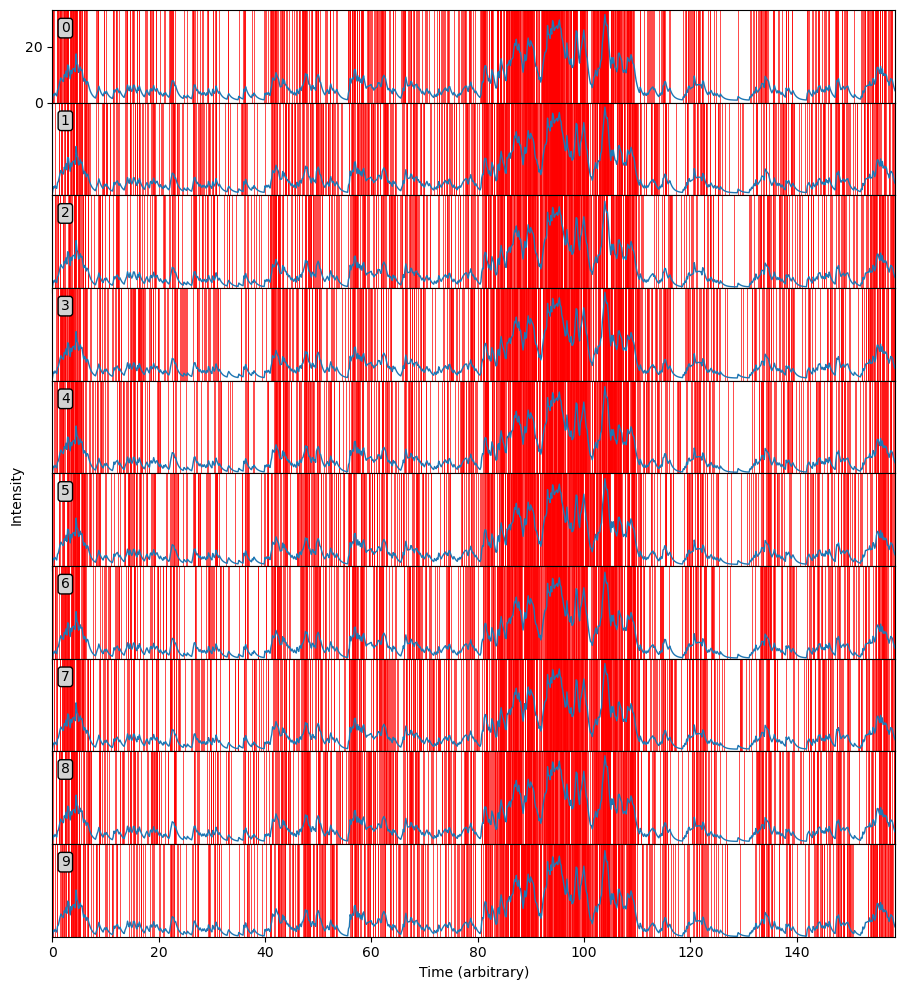

2026-04-07 11:26:40,217 - INFO - Saved event sequence to outputs/data/events.pt and simulation model to outputs/data/model_sim.pt


In [6]:
# Fixed simulation hyperparameters to imitate "hub-and-spoke" interaction behavior
# S = 0.1  # Spontaneous rate
I = 0.9  # Influence rate
sim_K = 1
sim_gamma = [1.5] * sim_K
sim_init_scale = 0.1
sim_alpha = [[0] * M for _ in range(M)]
sim_alpha[0] = [I] * M  # Hub influences all nodes including self

base_process = models.PoissonConstant(
    M=M,
    mu_init=torch.distributions.Uniform(0.0, 1.0).sample((M,)).to(device),
).to(device)

# Initialize model used for simulation
model_sim = models.HawkesFullRank(
    base_process=base_process,
    gamma=torch.tensor(sim_gamma).to(device),
    gamma_param=False,
    alpha_init=sim_init_scale,
    runtime_config=config.RuntimeConfig(deterministic_sim=True),
).to(device)


# Set base excitation and interaction rates according to fixed sim params
model_sim.alpha = torch.tensor(sim_alpha).to(device).unsqueeze(0).repeat(sim_K, 1, 1)

# Simulate the event sequence and generate intensity plot
seq = model_sim.simulate(max_events=N)
logger.info(f"Simulated event sequence of length {seq.N} in [0, {seq.T:.2f}]")

plotting.plot_intensity(seq, model_sim)

# Save simulated event sequence and simulation model
torch.save(seq, events_file)
torch.save(model_sim, model_sim_file)
logger.info(
    f"Saved event sequence to {events_file} "
    f"and simulation model to {model_sim_file}"
)

# Estimation

In [7]:
# Fit Hawkes process

WARM_START = False

# Obtain event sequence and reference interaction matrix
seq = torch.load(events_file, weights_only=False).to(device)

# Fitting hyperparameters
fit_config = config.FitConfig(
    num_steps=4000,
    batch_size=batch_size,
    monitor_interval=400,
    learning_rate=0.1,
)
est_gamma = [0.1, 0.5, 2.0]
est_init_scale = 0.1
est_rank = 3

base_process = models.PoissonConstant(M=seq.M, mu_init=0.01, device=device)

# Warm start for initializing the Hawkes process
if WARM_START:
    _ = base_process.fit(seq, None, None, fit_config)
    logger.info("Fitted base process")

# Fit estimation model
match model_type:
    case "full-rank":
        model_est = models.HawkesFullRank(
            gamma=torch.tensor(est_gamma).to(device),
            gamma_param=True,
            base_process=base_process,
            alpha_init=est_init_scale,
        ).to(device)
    case "low-rank":
        model_est = models.HawkesLowRank(
            rank=est_rank,
            gamma=torch.tensor(est_gamma).to(device),
            gamma_param=True,
            base_process=base_process,
            alpha_init=est_init_scale,
        ).to(device)
    case "upper-triangular":
        model_est = models.HawkesUpperTriangular(
            rank=est_rank,
            gamma=torch.tensor(est_gamma).to(device),
            gamma_param=True,
            base_process=base_process,
            alpha_init=est_init_scale,
        ).to(device)

_ = model_est.fit(seq, fit_config)

# Save estimated model
torch.save(model_est, model_est_file)
logger.info(f"Saved estimated model to {model_est_file}")

2026-04-07 11:26:40,227 - INFO - Starting Hawkes process training: HawkesFullRank with base process PoissonConstant
2026-04-07 11:26:40,228 - INFO - Configuration: M=10, K=3, N=10,000, T=158.52, lr=0.1, steps=4000
2026-04-07 11:26:40,228 - INFO - Device: cuda, model params: 313
2026-04-07 11:26:42,949 - INFO - Starting training loop...
2026-04-07 11:26:47,169 - INFO - Epoch 400/4000: Loss=-1.1507, Sparsity=0.930, α_mean=0.0301, γ=[0.29, 1, 1.8], μ_mean=0.5757
2026-04-07 11:26:51,347 - INFO - Epoch 800/4000: Loss=-1.1509, Sparsity=0.933, α_mean=0.0298, γ=[0.27, 1.2, 1.9], μ_mean=0.6284
2026-04-07 11:26:55,522 - INFO - Epoch 1200/4000: Loss=-1.1509, Sparsity=0.937, α_mean=0.0297, γ=[0.26, 1.2, 1.9], μ_mean=0.6402
2026-04-07 11:26:59,696 - INFO - Epoch 1600/4000: Loss=-1.1509, Sparsity=0.937, α_mean=0.0297, γ=[0.25, 1.2, 2], μ_mean=0.6444
2026-04-07 11:27:03,864 - INFO - Epoch 2000/4000: Loss=-1.1509, Sparsity=0.937, α_mean=0.0297, γ=[0.24, 1.2, 2], μ_mean=0.6467
2026-04-07 11:27:08,039 -

# Diagnostics

In [8]:
# Evaluate estimation performance

seq = torch.load("outputs/data/events.pt", weights_only=False)
model_sim = torch.load("outputs/data/model_sim.pt", weights_only=False)
model_est = torch.load("outputs/data/model_est.pt", weights_only=False)

# Relative L2 error between true and estimated base rates (base_process.mu as a function of time)
time_grid = torch.linspace(0, seq.T, 100000).to(device)
true_mu = model_sim.base_process.mu(time_grid)
est_mu = model_est.base_process.mu(time_grid)
relative_l2_error = (true_mu - est_mu).square().sum() / torch.norm(true_mu).square()
print(f"Base rate relative L2 error: {relative_l2_error:.2%}")

# RRMSE between true and estimated alpha matrices
true_alpha = model_sim.alpha.detach().sum(dim=0).cpu()
est_alpha = model_est.alpha.detach().sum(dim=0).cpu()
alpha_rrmse = (
    (true_alpha - est_alpha).square().sum() / true_alpha.square().sum()
).sqrt()
print(f"Alpha matrix RRMSE: {alpha_rrmse:.2%}")

Base rate relative L2 error: 15.93%
Alpha matrix RRMSE: 9.77%


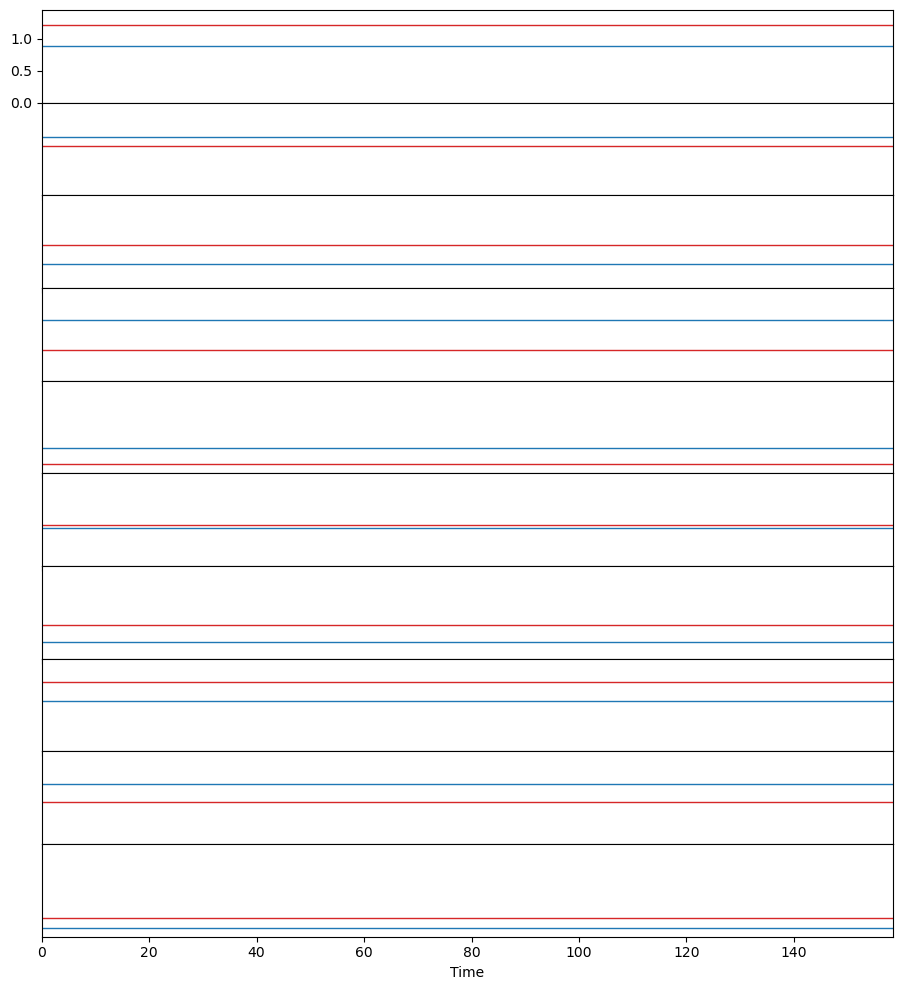

In [9]:
# Plot estimated vs true base rate

fig, ax = plt.subplots(seq.M, 1, figsize=(9, seq.M), sharex=True, sharey=False)

t_seq = torch.linspace(0, seq.T, 1000).to(device)
sim_mu = model_sim.base_process.mu(t_seq).detach()
est_mu = model_est.base_process.mu(t_seq).detach()

for m in range(seq.M):
    ax[m].plot(
        t_seq.cpu(),
        sim_mu[:, m].cpu(),
        label="True Base Rate",
        color="tab:blue",
        linewidth=1,
    )
    ax[m].plot(
        t_seq.cpu(),
        est_mu[:, m].cpu(),
        label="Estimated Base Rate",
        color="tab:red",
        linewidth=1,
    )

    ax[m].set_xlim(0, seq.ti.max().item())
    ax[m].set_ylim(
        0,
        max(sim_mu.max().item(), est_mu.max().item()) * 1.2,
    )

    if m > 0:
        ax[m].set_yticklabels([])
        ax[m].set_yticks([])

    if m == seq.M - 1:
        ax[m].set_xlabel("Time (arbitrary)")

plt.xlabel("Time")
plt.tight_layout()
fig.subplots_adjust(hspace=0)

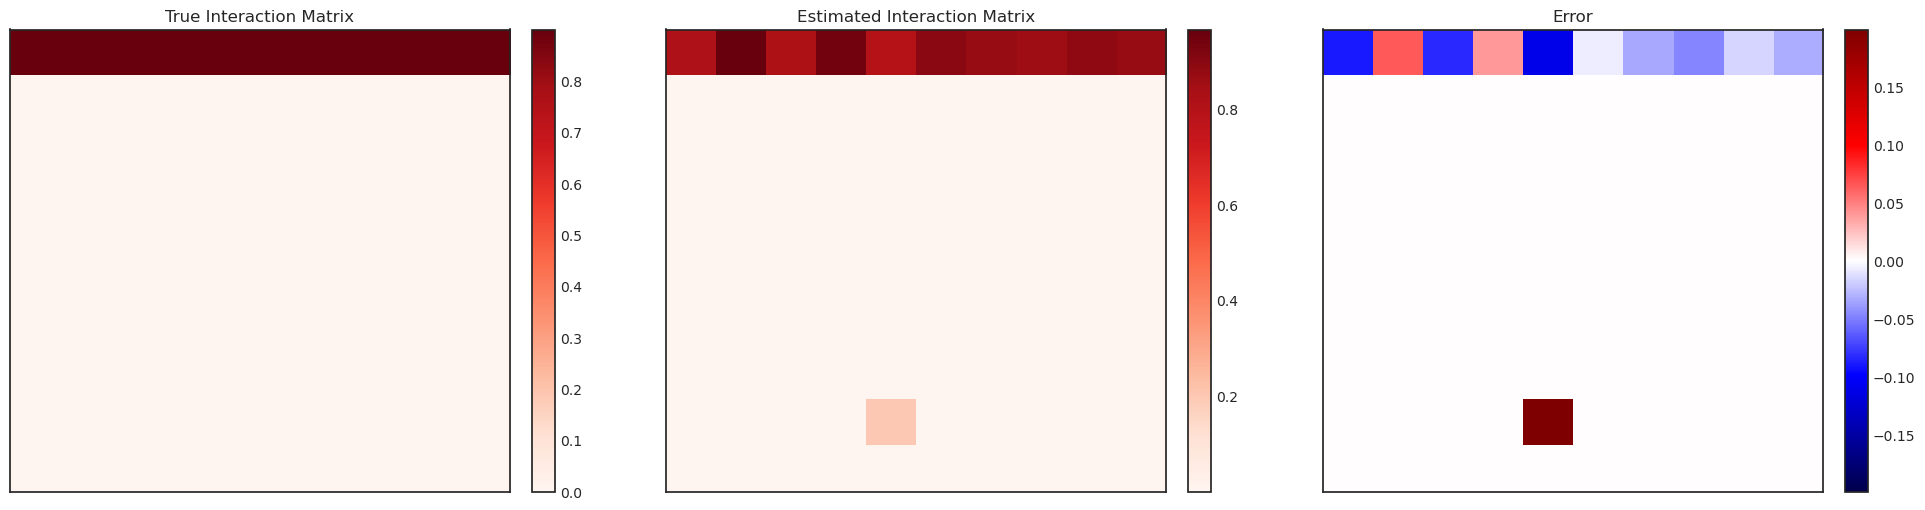

In [10]:
# Plot interaction matrix

plotting.plot_diagnostic(
    true_alpha=model_sim.alpha.detach().cpu().sum(axis=0),
    estimated_alpha=model_est.alpha.detach().cpu().sum(axis=0),
)

In [11]:
# Anderson-Darling and Kolmogorov-Smirnov tests on rescaled inter-event times

states = model_est.intensity_states(seq)
rescaled_times = model_est.rescaled_times(seq, states)
tau = rescaled_times.sum(dim=1).detach().cpu().numpy()

print("Summary:")
print(tau.mean(), tau.std())
print(np.min(tau), np.max(tau))
print()

result = sp.stats.anderson(tau.clip(1e-10), dist="expon")
print("Anderson-Darling statistic: ", result.statistic)
print("Reject:")
for val, res in zip(
    result.statistic > result.critical_values, result.significance_level
):
    print(f"  {res}%: {val}")
print()

result = sp.stats.kstest(tau, "expon")
print("Kolmogorov-Smirnov statistic: ", result.statistic)
print("p-value: ", result.pvalue)
print("Reject: ", result.pvalue < 0.05)

Summary:
1.0003872 0.9934582
0.0 10.607706

Anderson-Darling statistic:  0.34373056031654414
Reject:
  15.0%: False
  10.0%: False
  5.0%: False
  2.5%: False
  1.0%: False

Kolmogorov-Smirnov statistic:  0.005592397594713083
p-value:  0.9114891876937411
Reject:  False


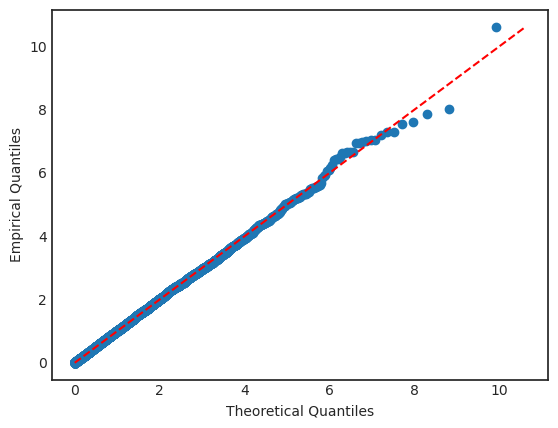

In [12]:
# Q-Q plot versus Exp(1)

tau_sorted = np.sort(tau)

n = len(tau_sorted)
p = (np.arange(1, n + 1) - 0.5) / n

theoretical_quantiles = -np.log(1 - p)

plt.plot(theoretical_quantiles, tau_sorted, "o")
plt.plot(
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    linestyle="--",
    color="red",
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Empirical Quantiles")
plt.show()